# Descriptive-Title
Felix Zaussinger | 26.08.2022

**Core Analysis Goal(s)**
1. Create industry and regional plots based on final GBN classification (weighted and unweighted)

**Key Insight(s)**
1.
2.
3.

In [6]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("poster")
sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# preprocessing flag
reprocess = False

Read unweighted GBN shares at ISCO 3-digit level

In [8]:
gbn_shares_no_wt = pd.read_pickle(os.path.join(useful_paths.data_processed, "esco", "final_gbn_shares_by_isco_unweighted.pkl"))

gbn_shares_no_wt_sl = gbn_shares_no_wt.query("isco_level == 3 & list_version == 'short_list'")
gbn_shares_no_wt_slt = gbn_shares_no_wt.query("isco_level == 3 & list_version == 'short_list_tobi'")

In [9]:
gbn_shares_no_wt = pd.merge(
    gbn_shares_no_wt_sl[["isco_code", "preferredLabel_isco", "share_green", "share_brown", "share_neutral"]],
    gbn_shares_no_wt_slt[["isco_code", "share_brown", "share_neutral"]],
    on="isco_code",
    how="left",
    suffixes=["_sl", "_slt"]
)

gbn_shares_no_wt = gbn_shares_no_wt.rename(columns={"preferredLabel_isco": "ISCO3D_label"})
gbn_shares_no_wt["NOBS"] = 1
gbn_shares_no_wt

gbn_classification_short_list,isco_code,ISCO3D_label,share_green,share_brown_sl,share_neutral_sl,share_brown_slt,share_neutral_slt,NOBS
0,011,Commissioned armed forces officers,0.00,0.0,1.00,0.0,1.00,1
1,021,Non-commissioned armed forces officers,0.00,0.0,1.00,0.0,1.00,1
2,031,"Armed forces occupations, other ranks",0.00,0.0,1.00,0.0,1.00,1
3,111,Legislators and senior officials,0.00,0.0,1.00,0.0,1.00,1
4,112,Managing directors and chief executives,0.00,0.0,1.00,0.0,1.00,1
...,...,...,...,...,...,...,...,...
120,941,Food preparation assistants,0.00,0.0,1.00,0.0,1.00,1
121,951,Street and related service workers,0.00,0.0,1.00,0.0,1.00,1
122,952,Street vendors (excluding food),0.00,0.0,1.00,0.0,1.00,1
123,961,Refuse workers,0.75,0.0,0.25,0.0,0.25,1


#### Prepare EU-LFS data

In [10]:
from src.data.lfs import EuLfs
from src.data.framework import Classifications

# for NACE labels
classifications = Classifications()
covariates_by_nace = classifications.nace_1d

# load config file of EU-LFS data
config = utils.load_config(
    os.path.join(useful_paths.config_dir, "eu_lfs_config.yml")
)

# create object
lfs = EuLfs(config=config)

Pre-process data

Countries with data limitations:
•	ISCO-08 2D: BG, PL
•	ISCO-08 1D: MT
•	NUTS 1: UK
•	NUTS Suppressed: NL

Countries removed for ISCO-08 3D results:
- BG
- PL
- MT

Possibilities for dropping observations:
- ISCO not coded at 3D (but at 2 or 1D)
- COEFF is NAN
- ISCO3D is 633 (subsistence farming --> investigate: https://esco.ec.europa.eu/en/classification/occupation?uri=http://data.europa.eu/esco/isco/C633)

In [11]:
countries_isco3d = [
    'AT',
    'BE',
    'CH',
    'CY',
    'CZ',
    'DE',
    'DK',
    'EE',
    'ES',
    'FI',
    'FR',
    'GR',
    'HR',
    'HU',
    'IE',
    'IS',
    'IT',
    'LT',
    'LU',
    'LV',
    'NL',
    'NO',
    'PT',
    'RO',
    'SE',
    'SK',
    'UK'
]

In [12]:
if reprocess:
    lfs.preprocess_files(
        years=[2019],
        countries=countries_isco3d,
        save_file=True,
        optional_output_dir=config["paths"]["interim"],
        output_fname="eu_lfs_merged_{year}",
    )

Join final unweighted shares

In [13]:
if reprocess:
    lfs.join_covariates(
    year=2019,
    optional_input_dir=config["paths"]["interim"],
    input_fname_lfs="eu_lfs_merged_{year}",
    covariates_by_isco=gbn_shares_no_wt,
    covariates_by_nace=covariates_by_nace,
    optional_output_dir=config["paths"]["interim"],
    output_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares",
    isco_covariate_selection=None,
)

Aggregate data by regions, industries and occupations

In [14]:
# aggregate
agg_dict = {
    "COEFF": np.sum,
    "NOBS": np.sum,
    "COEFF_share_green": np.sum,
    "COEFF_share_brown_sl": np.sum,
    "COEFF_share_brown_slt": np.sum,
}

if reprocess:
    # by 1-digit industry
    lfs.aggregate(
        year=2019,
        group_by=["NACE1D_label"],
        agg_dict=agg_dict,
        input_fname="eu_lfs_merged_{year}_with_final_unweighted_shares",
        output_fname="eulfs_{year}_by_{by}_final_unweighted_shares"
    )

    # by 1-digit industry and country
    lfs.aggregate(
        year=2019,
        group_by=["NACE1D_label", "COUNTRYW"],
        agg_dict=agg_dict,
        input_fname="eu_lfs_merged_{year}_with_final_unweighted_shares",
        output_fname="eulfs_{year}_by_{by}_final_unweighted_shares"
    )

    # by nuts-2 regions and 1-digit industries
    lfs.aggregate(
        year=2019,
        group_by=["NUTS_ID", "NACE1D_label"],
        agg_dict=agg_dict,
        input_fname="eu_lfs_merged_{year}_with_final_unweighted_shares",
        output_fname="eulfs_{year}_by_{by}_final_unweighted_shares"
    )

#### Visualisation

In [15]:
from src.visualization.visualize import EulfsVis

config_paths = "paths_config.yml"
config_data = "data_config.yml"
config_vis = "vis_config.yml"

# EU-LFS
eulfs_visualiser = EulfsVis(
    fn_config_data=config_data,
    fn_config_path=config_paths,
    fn_vis_config=config_vis,
    year=2019,
)

In [60]:
data_panel_new = pd.read_pickle(os.path.join(config["paths"]["interim"], "eu_lfs_merged_{year}_with_final_unweighted_shares.pkl".format(year=2019)))
data_panel_new = data_panel_new.dropna(subset=["COEFF", "ISCO3D_label"])
eulfs_visualiser.data_panel = data_panel_new

#### Incorporate publication guidelines by Eurostat (thresholds for sample sizes, etc.)

In all reports, including both published and unpublished papers, three thresholds related to cell size will be distinguished for LFS results:
- Confidentiality threshold - below three observations (unweighted sample), results must not be published;
- Reliability thresholds - regarding reliability restrictions, Eurostat defines two limits, called 'a' and 'b'. Reliability limits depend on the sample size and design in the individual Member States.
    - Estimates corresponding to a (weighted) population below limit 'a' must not be published;
    - Estimates corresponding to a (weighted) population between limit 'a' and limit ‘b’ may be published with a warning concerning their limited reliability. This applies to quarterly data, annual averages of quarterly data, yearly data and ad hoc module results. The limits vary across Member States, years, and type of dataset. The thresholds “a” and “b” are provided in the CSV files in the “datafileinfo” folders in the anonymised microdata releases. More information can be found also at the LFS Statistics Explained pages, section “Publication guidelines and thresholds”.

See: C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\datafileinfo

In [62]:
threshold_a = 3

Check availability of ISCO-08 3-digit data for countries

In [17]:
data_panel_new.COUNTRYW.unique()

['AT', 'BE', 'CH', 'CY', 'CZ', ..., 'PT', 'RO', 'SE', 'SK', 'UK']
Length: 27
Categories (27, object): ['AT', 'BE', 'CH', 'CY', ..., 'RO', 'SE', 'SK', 'UK']

Define cols to process and plot

In [18]:
cols_to_calc = [
    "COEFF_share_green",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

cols_to_aggregate = [
    "COEFF",
    "COEFF_share_green",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

cols_to_plot = [
    "COEFF_share_green_relative",
    "COEFF_share_brown_sl_relative",
    "COEFF_share_brown_slt_relative",
]

Plot (by industry)

In [19]:
eulfs_visualiser.create_industry_barplots(
    year=2019,
    cols_to_aggregate=cols_to_aggregate,
    cols_to_plot=cols_to_plot,
    out_dir=os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "{year}",
        "employment_shares_by_industry",
    )
)

INFO:src.visualization.visualize:GBN employment shares by industry.
plotting variable: COEFF_share_green_relative
plotting variable: COEFF_share_brown_sl_relative
plotting variable: COEFF_share_brown_slt_relative


Plot (by region)

In [20]:
eulfs_visualiser.cols_to_calc_all = cols_to_aggregate
eulfs_visualiser.cols_to_calc = cols_to_calc

Aggregate

In [73]:
eulfs_visualiser.create_maps(
    slice_by_industry=False,
    vmin=0,
    vmax=0.03,
    cmap="Greys",
    n_cats=3,
    out_dir=os.path.join(
            useful_paths.figure_dir,
            "03_eulfs",
            "2019",
            "employment_shares_by_region",
            "NEW",
            "cbars_fixed_at_3_percent_discrete"
        ),
)

INFO:src.visualization.visualize:GBN employment shares by region.
COEFF_share_green_relative
\\gess-fs.d.ethz.ch\home$\fzaussinger\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\results\figures\03_eulfs\2019\employment_shares_by_region\NEW\cbars_fixed_at_3_percent_discrete
COEFF_share_brown_sl_relative
\\gess-fs.d.ethz.ch\home$\fzaussinger\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\results\figures\03_eulfs\2019\employment_shares_by_region\NEW\cbars_fixed_at_3_percent_discrete
COEFF_share_brown_slt_relative
\\gess-fs.d.ethz.ch\home$\fzaussinger\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\results\figures\03_eulfs\2019\employment_shares_by_region\NEW\cbars_fixed_at_3_percent_discrete


By industry

INFO:src.visualization.visualize:GBN employment shares by region.
Agriculture, Forestry and Fishing
COEFF_share_green_relative
\\gess-fs.d.ethz.ch\home$\fzaussinger\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\results\figures\03_eulfs\2019\employment_shares_by_region\NEW\by_industry\0_Agriculture, Forestry and Fishing
COEFF_share_brown_sl_relative
\\gess-fs.d.ethz.ch\home$\fzaussinger\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\results\figures\03_eulfs\2019\employment_shares_by_region\NEW\by_industry\0_Agriculture, Forestry and Fishing
COEFF_share_brown_slt_relative
\\gess-fs.d.ethz.ch\home$\fzaussinger\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\results\figures\03_eulfs\2019\employment_shares_by_region\NEW\by_industry\0_Agriculture, Forestry and Fishing
Mining and Quarrying
COEFF_share_green_relative
\\gess-fs.d.ethz.ch\home$\fzaussinger\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4g

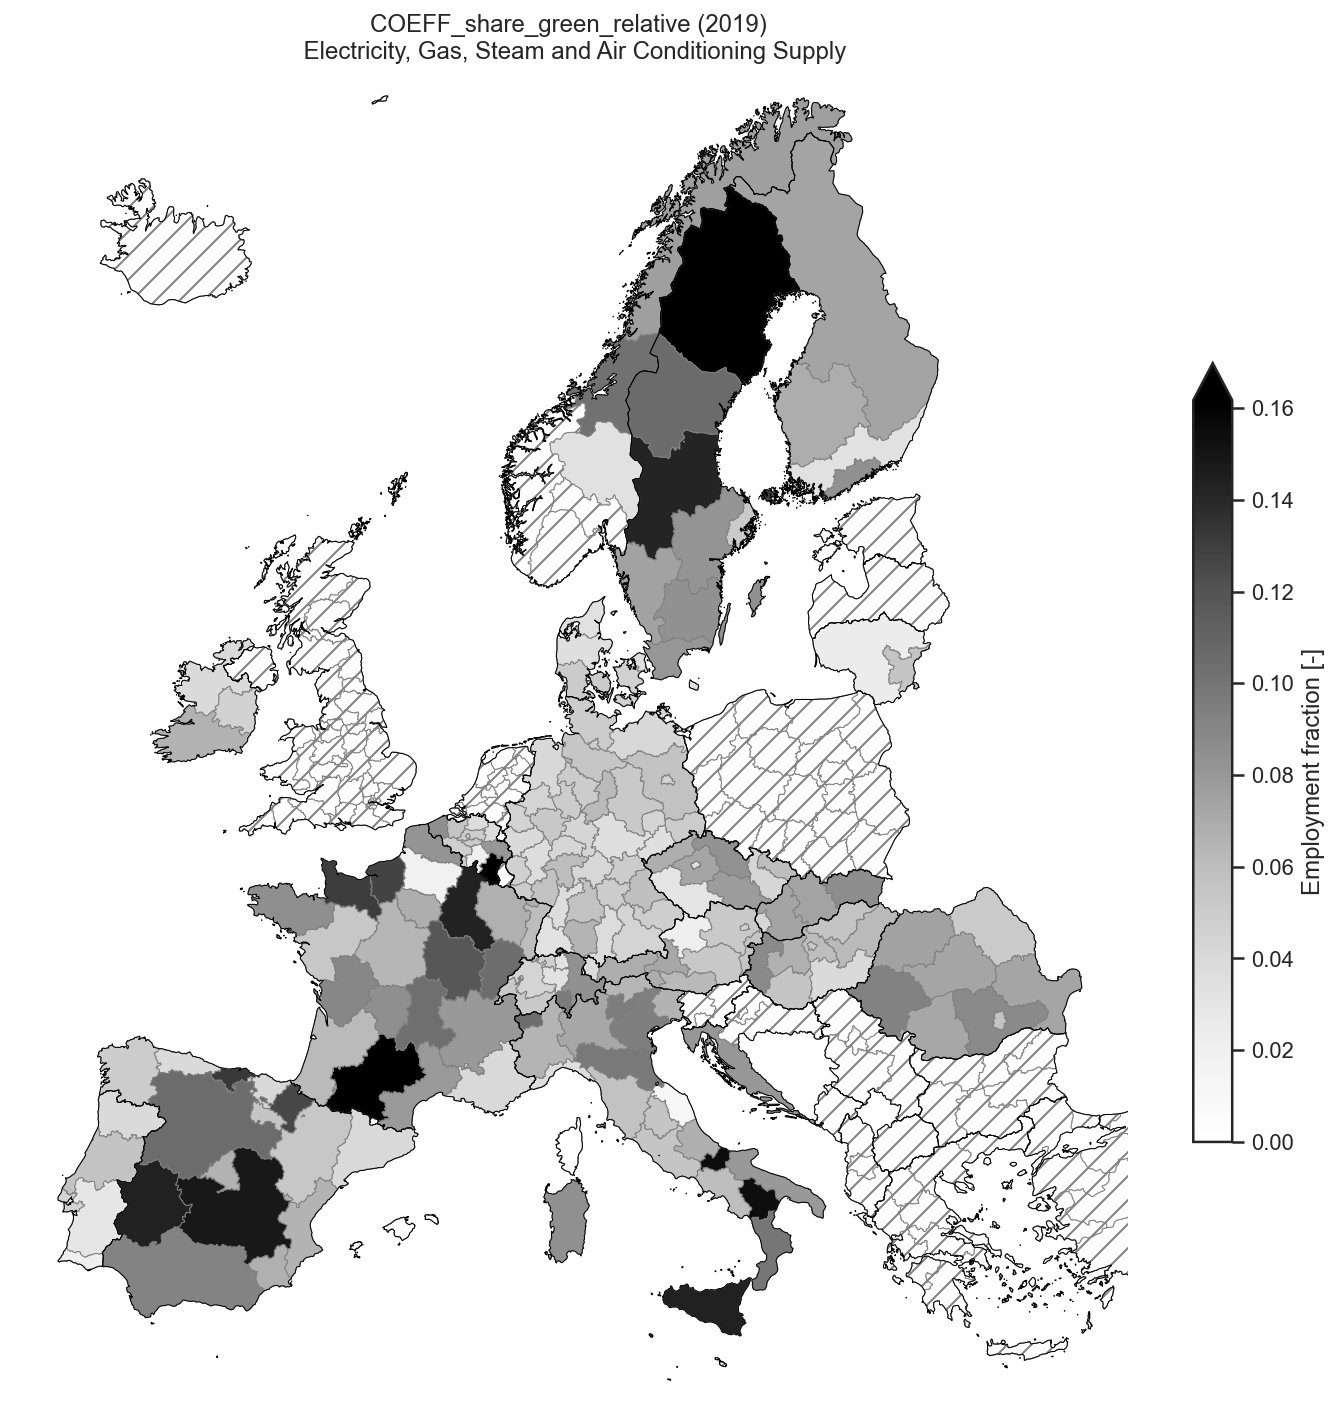

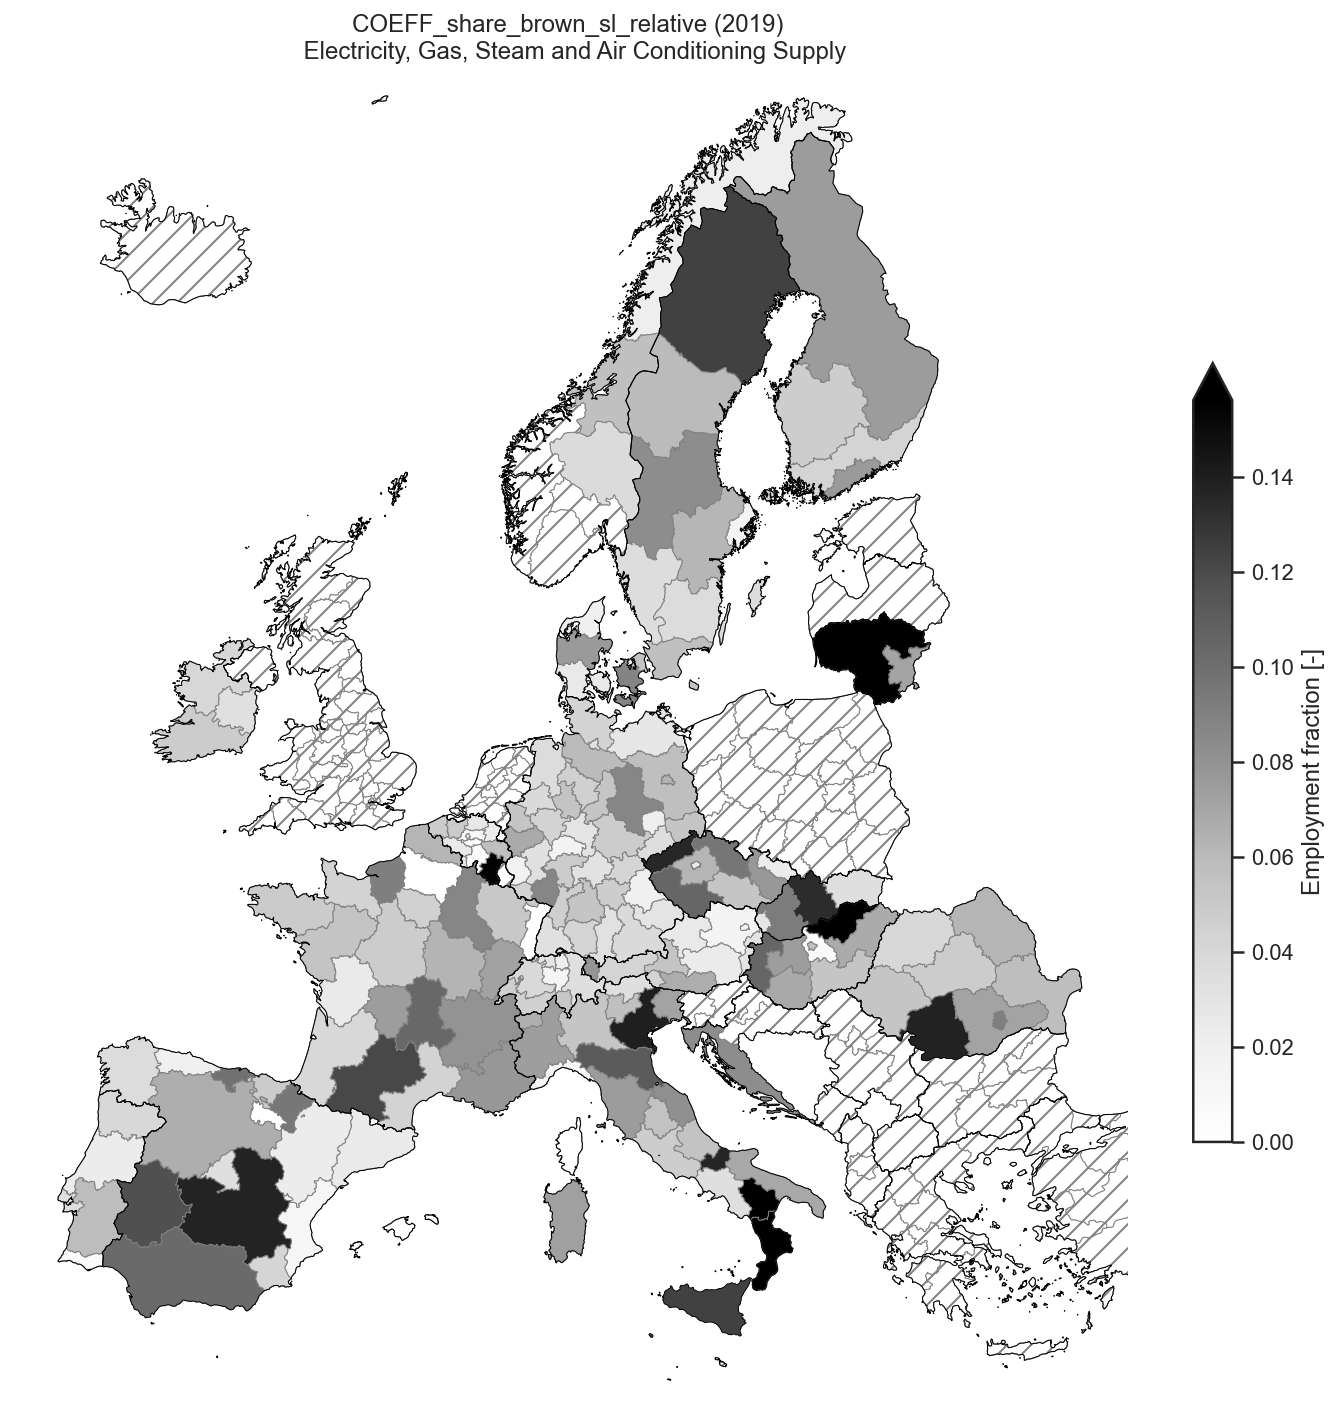

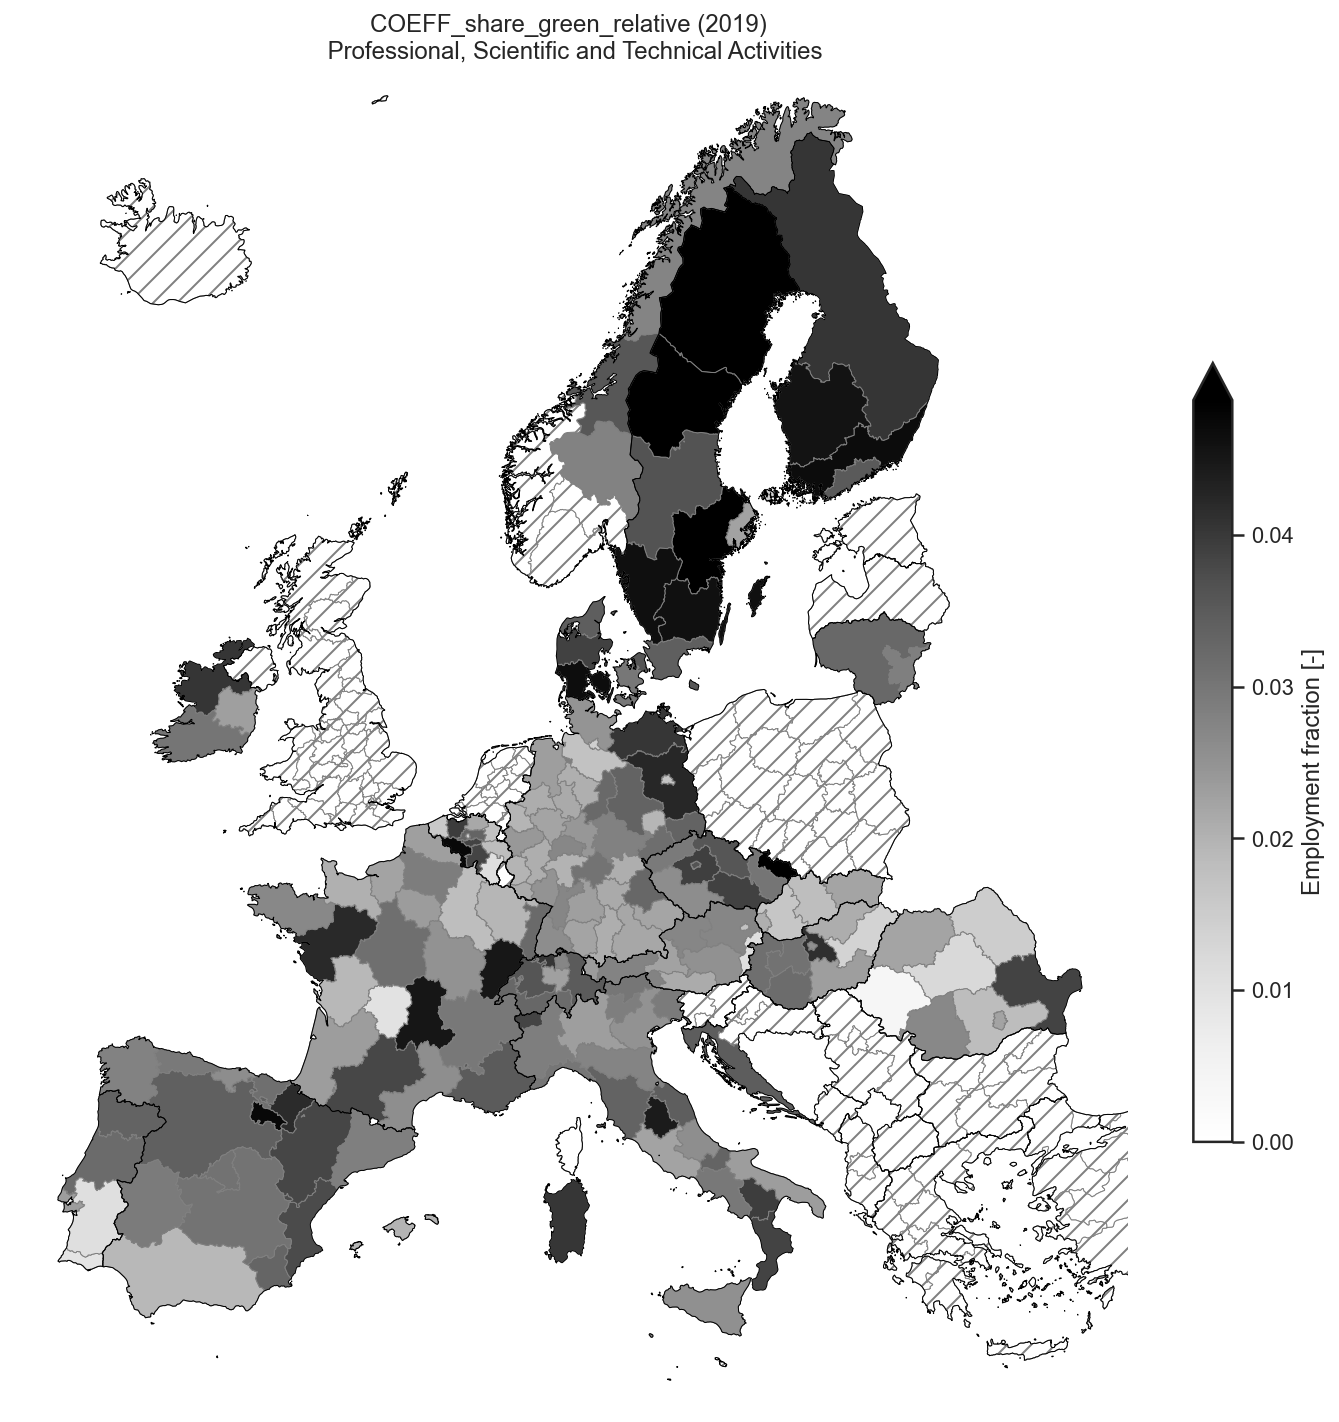

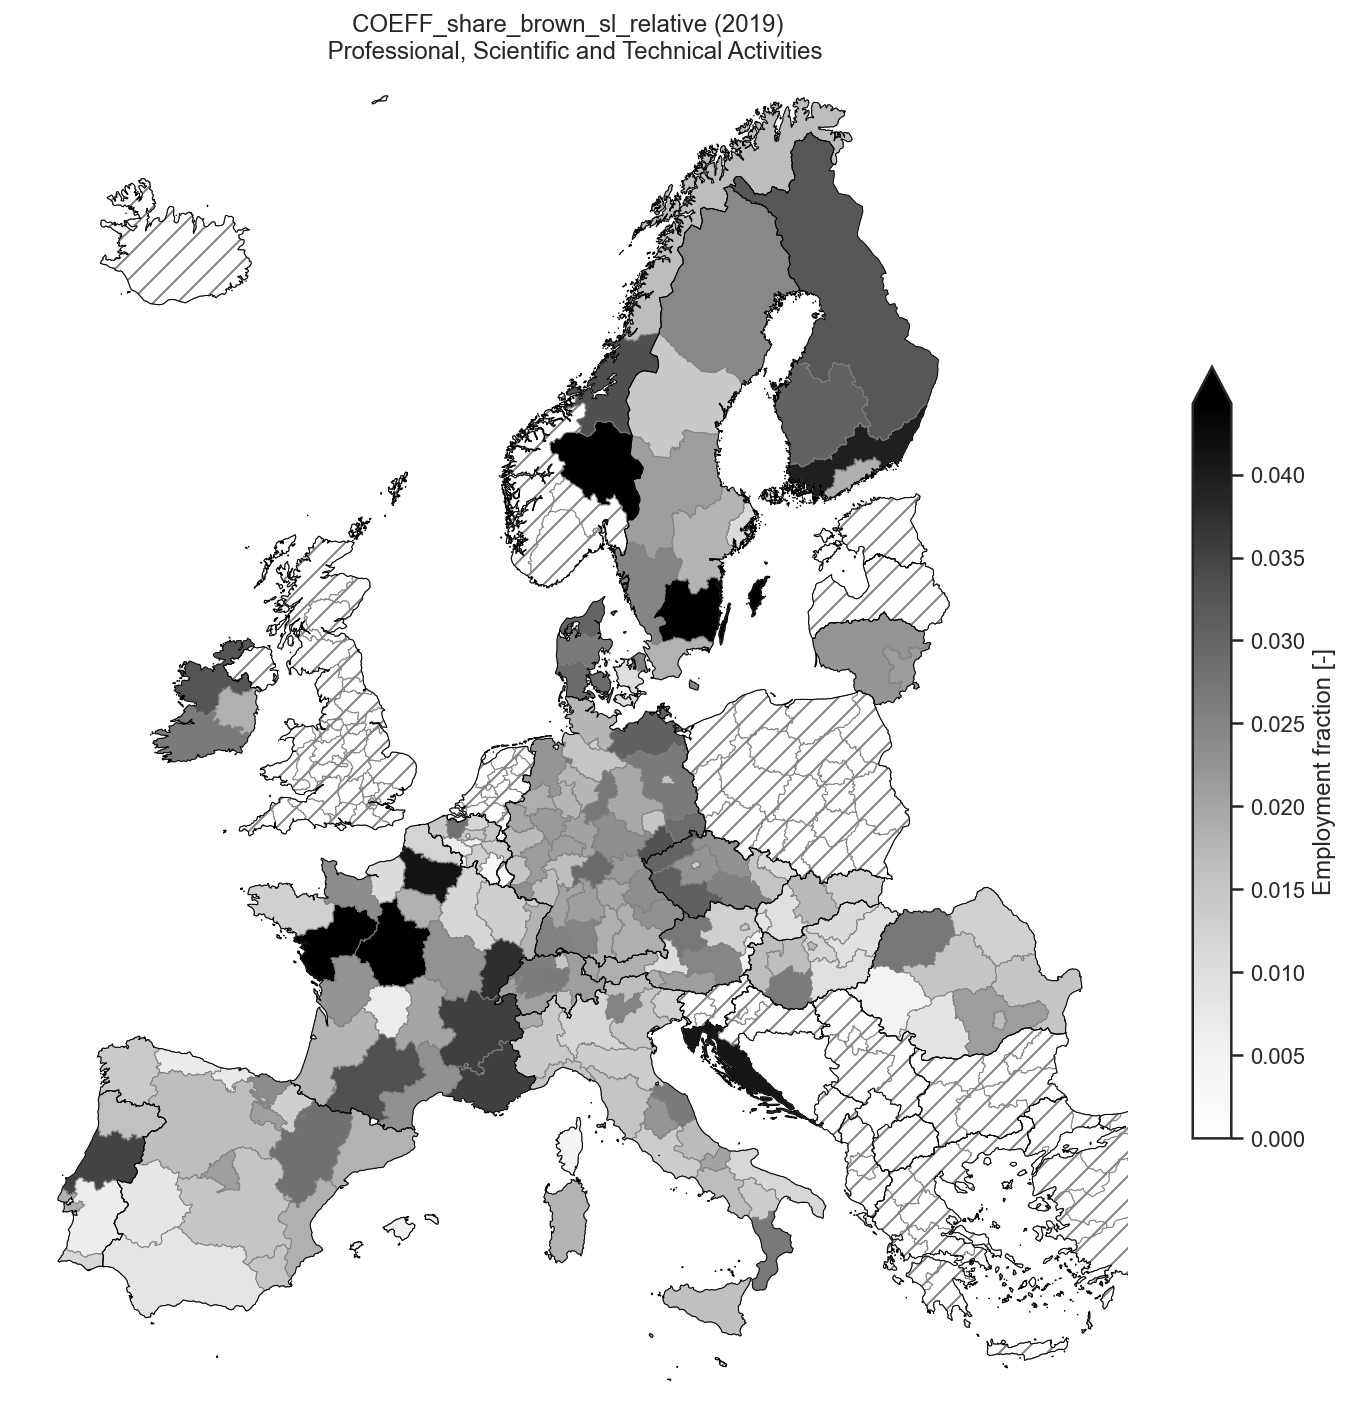

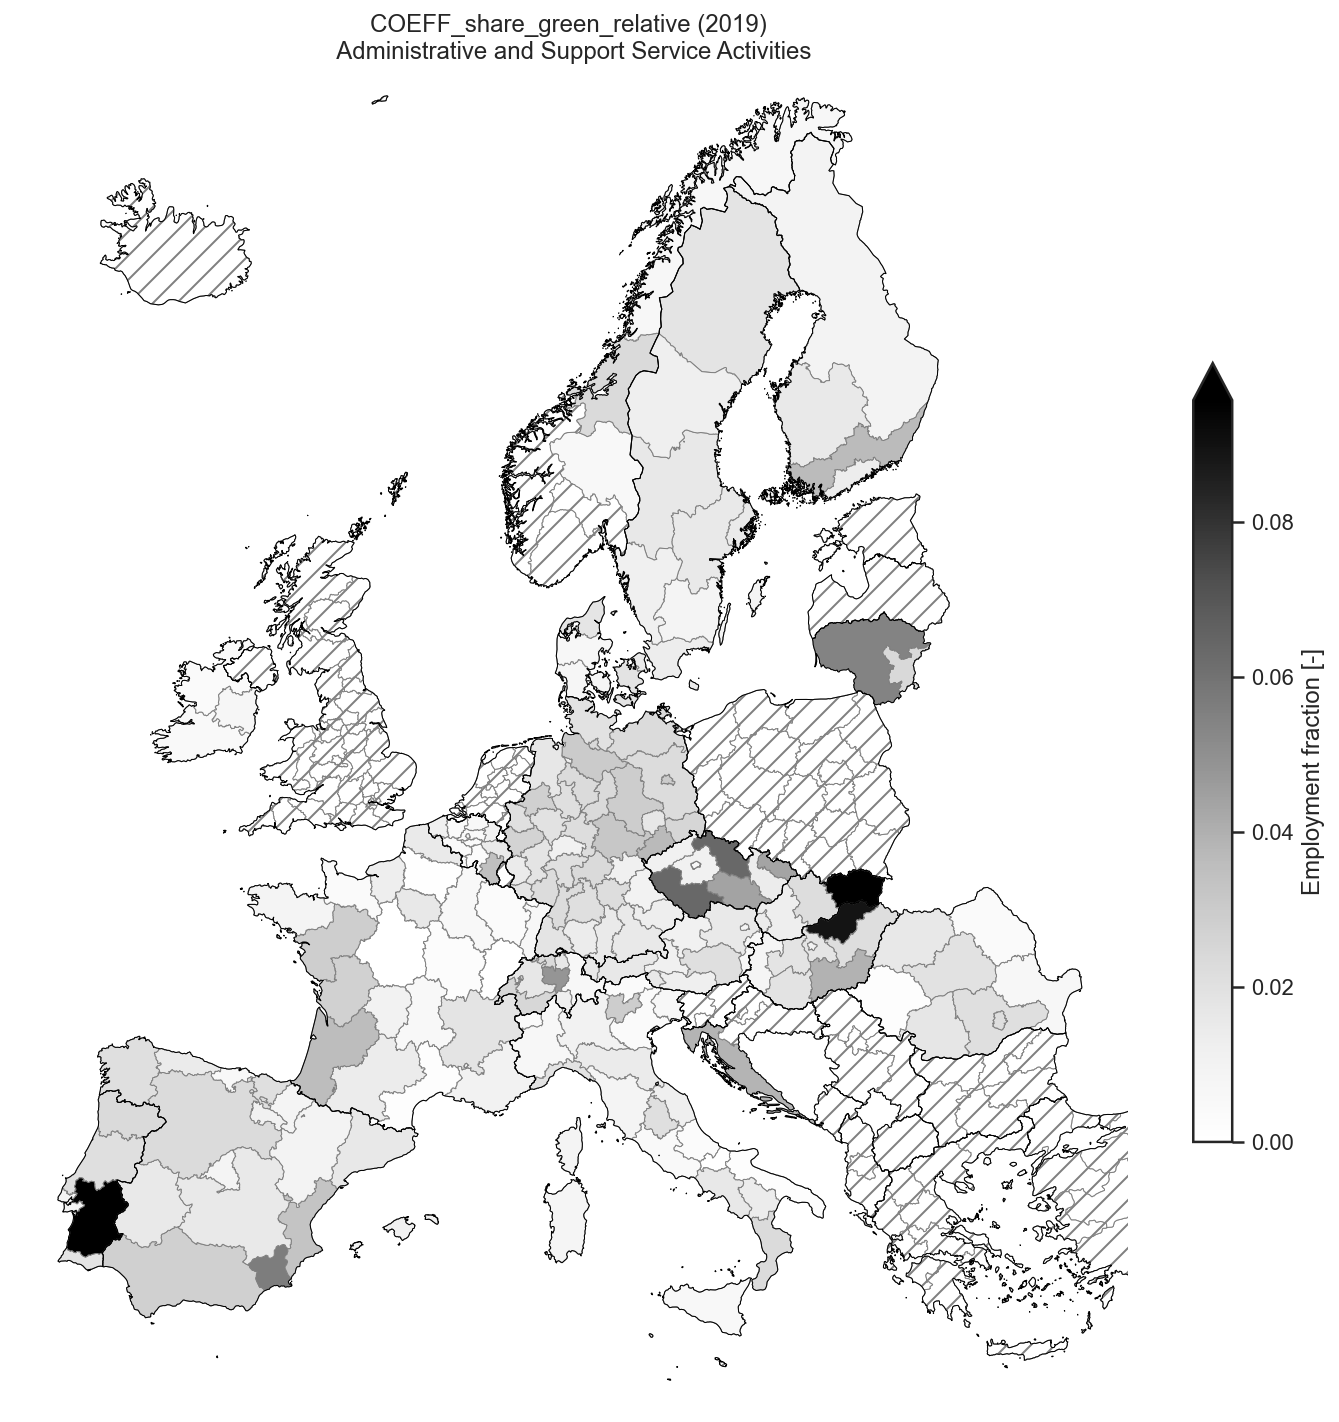

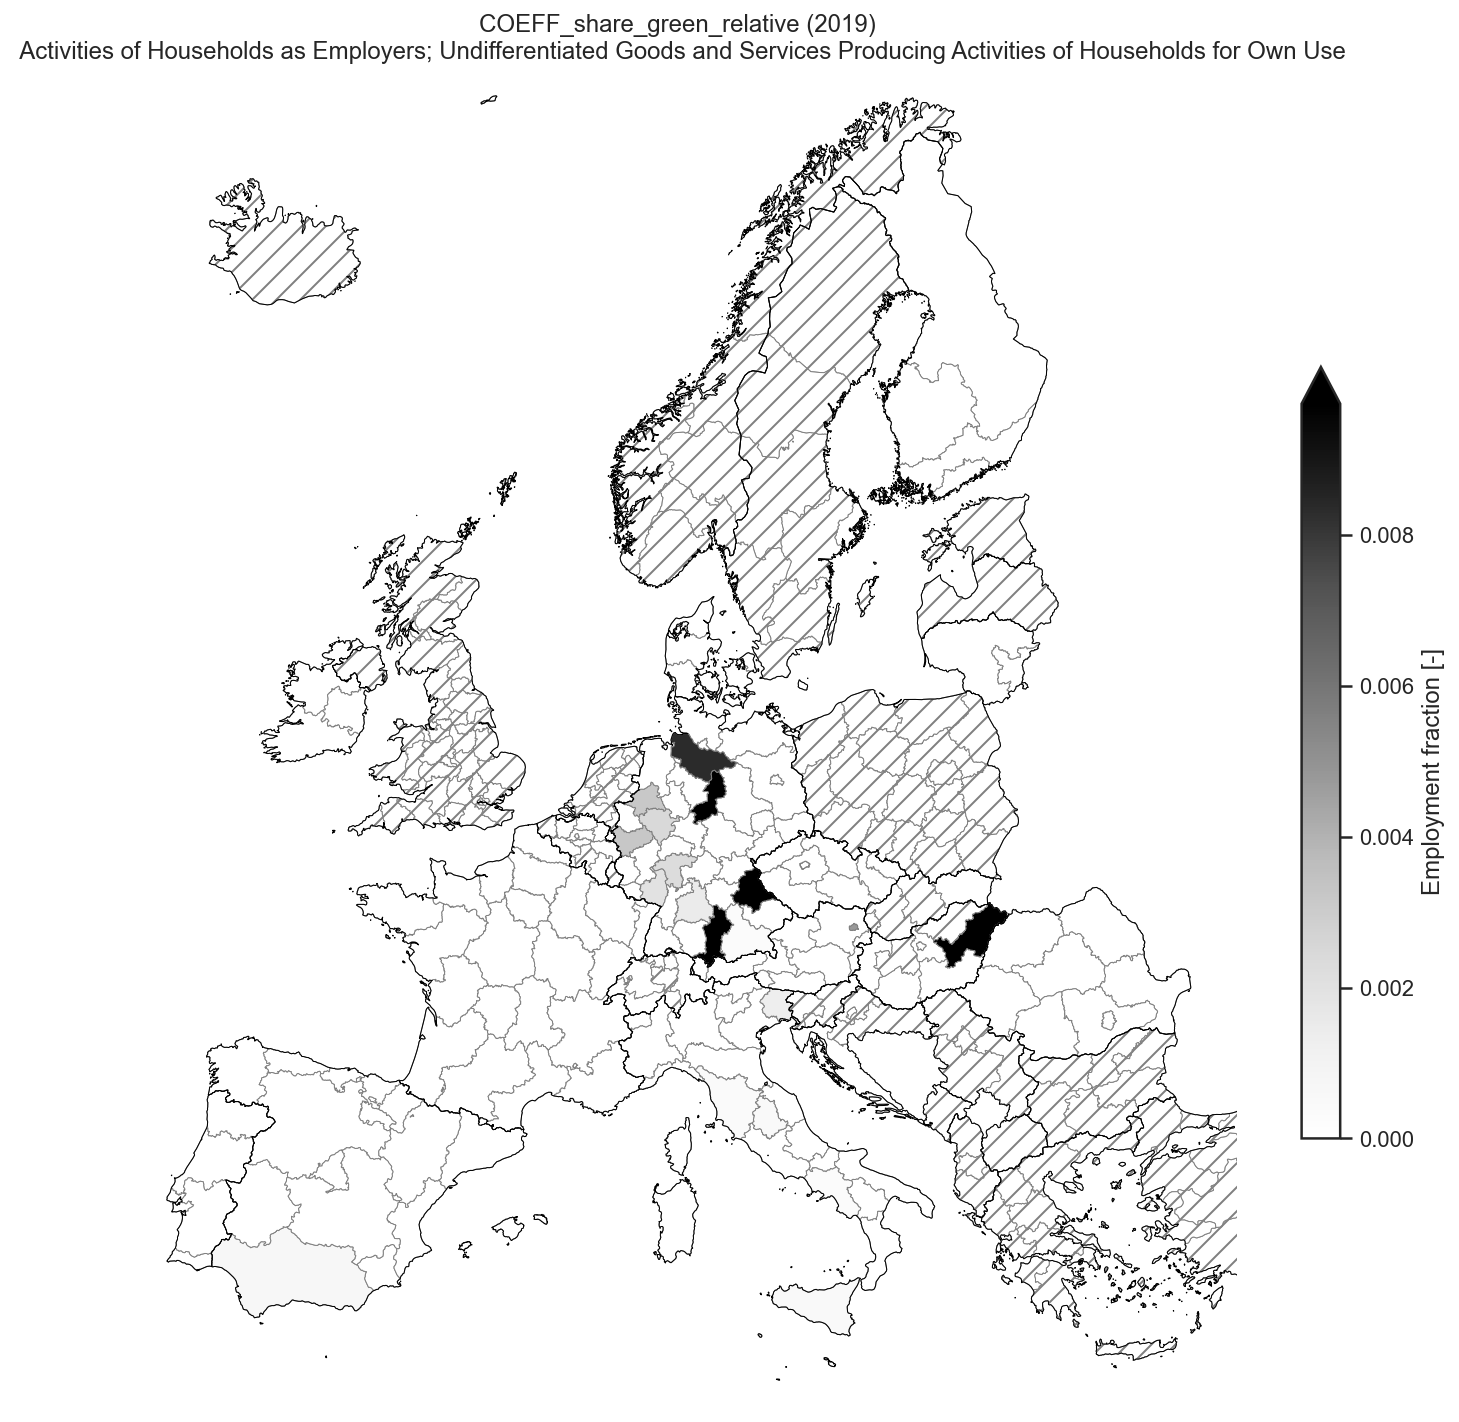

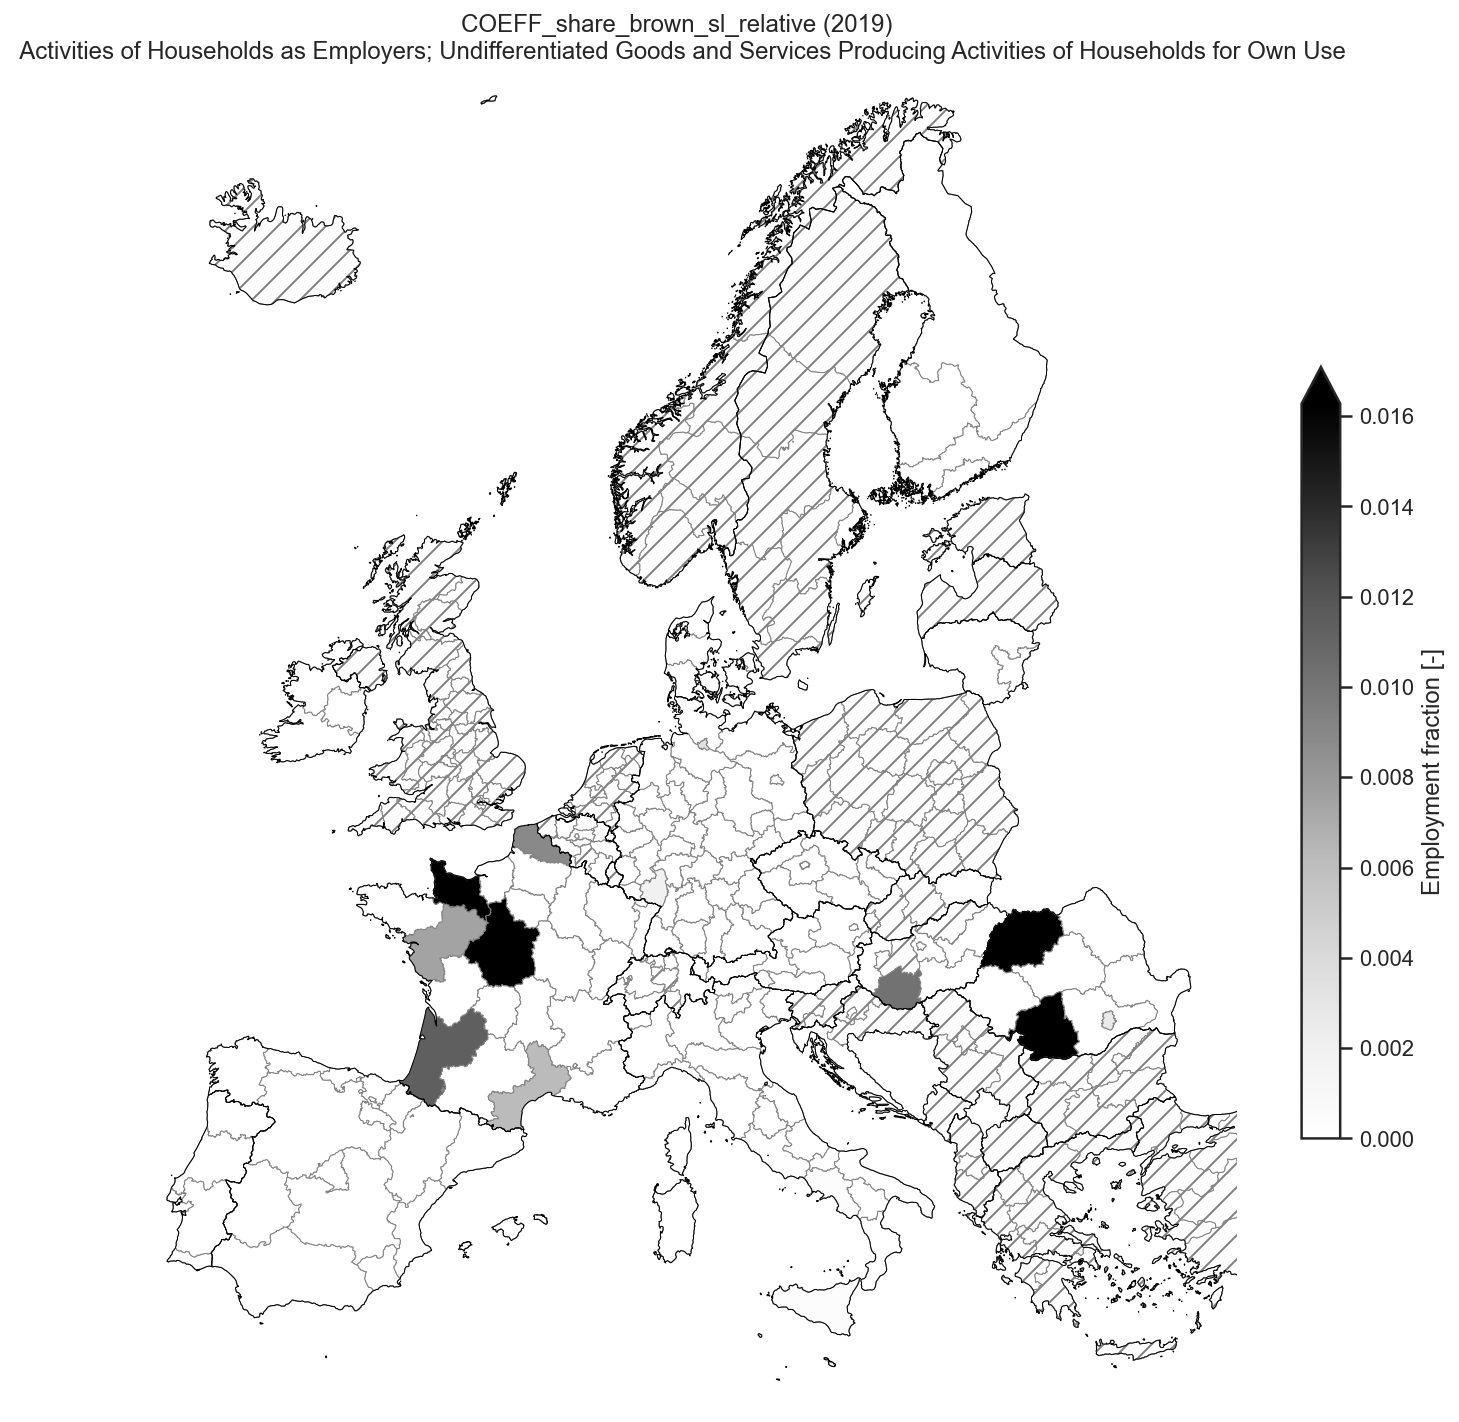

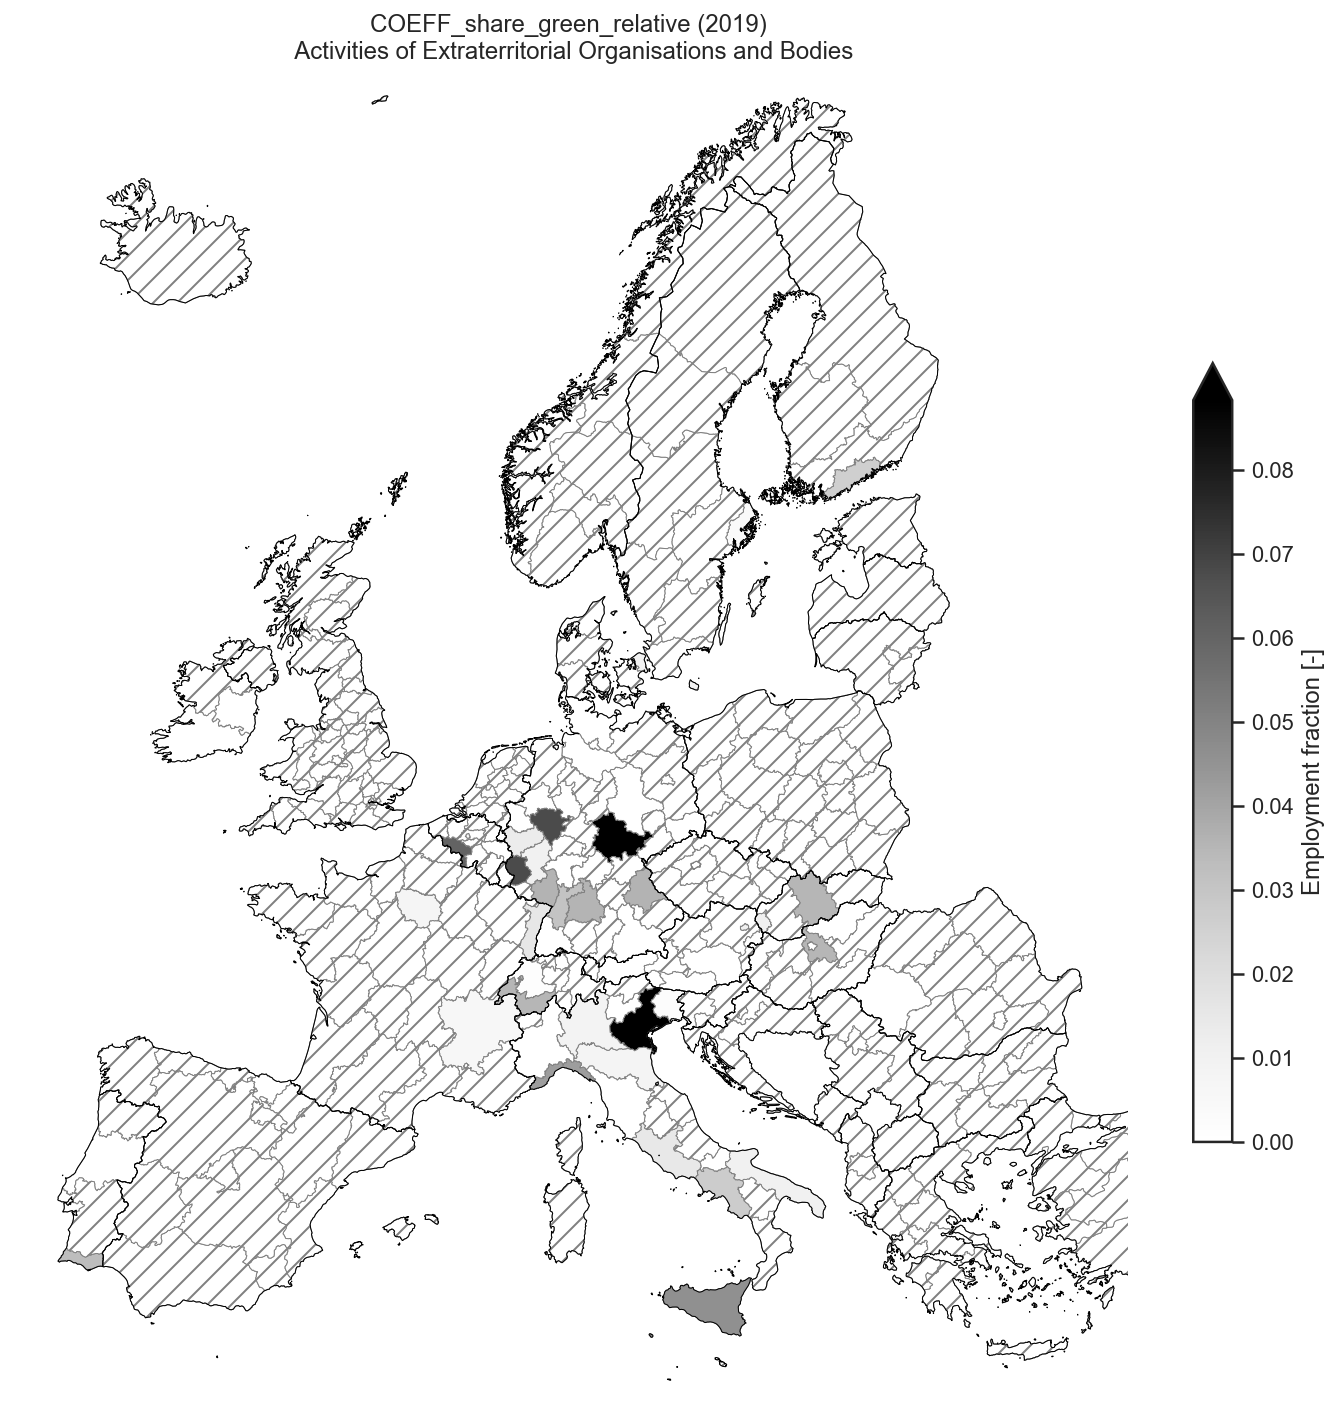

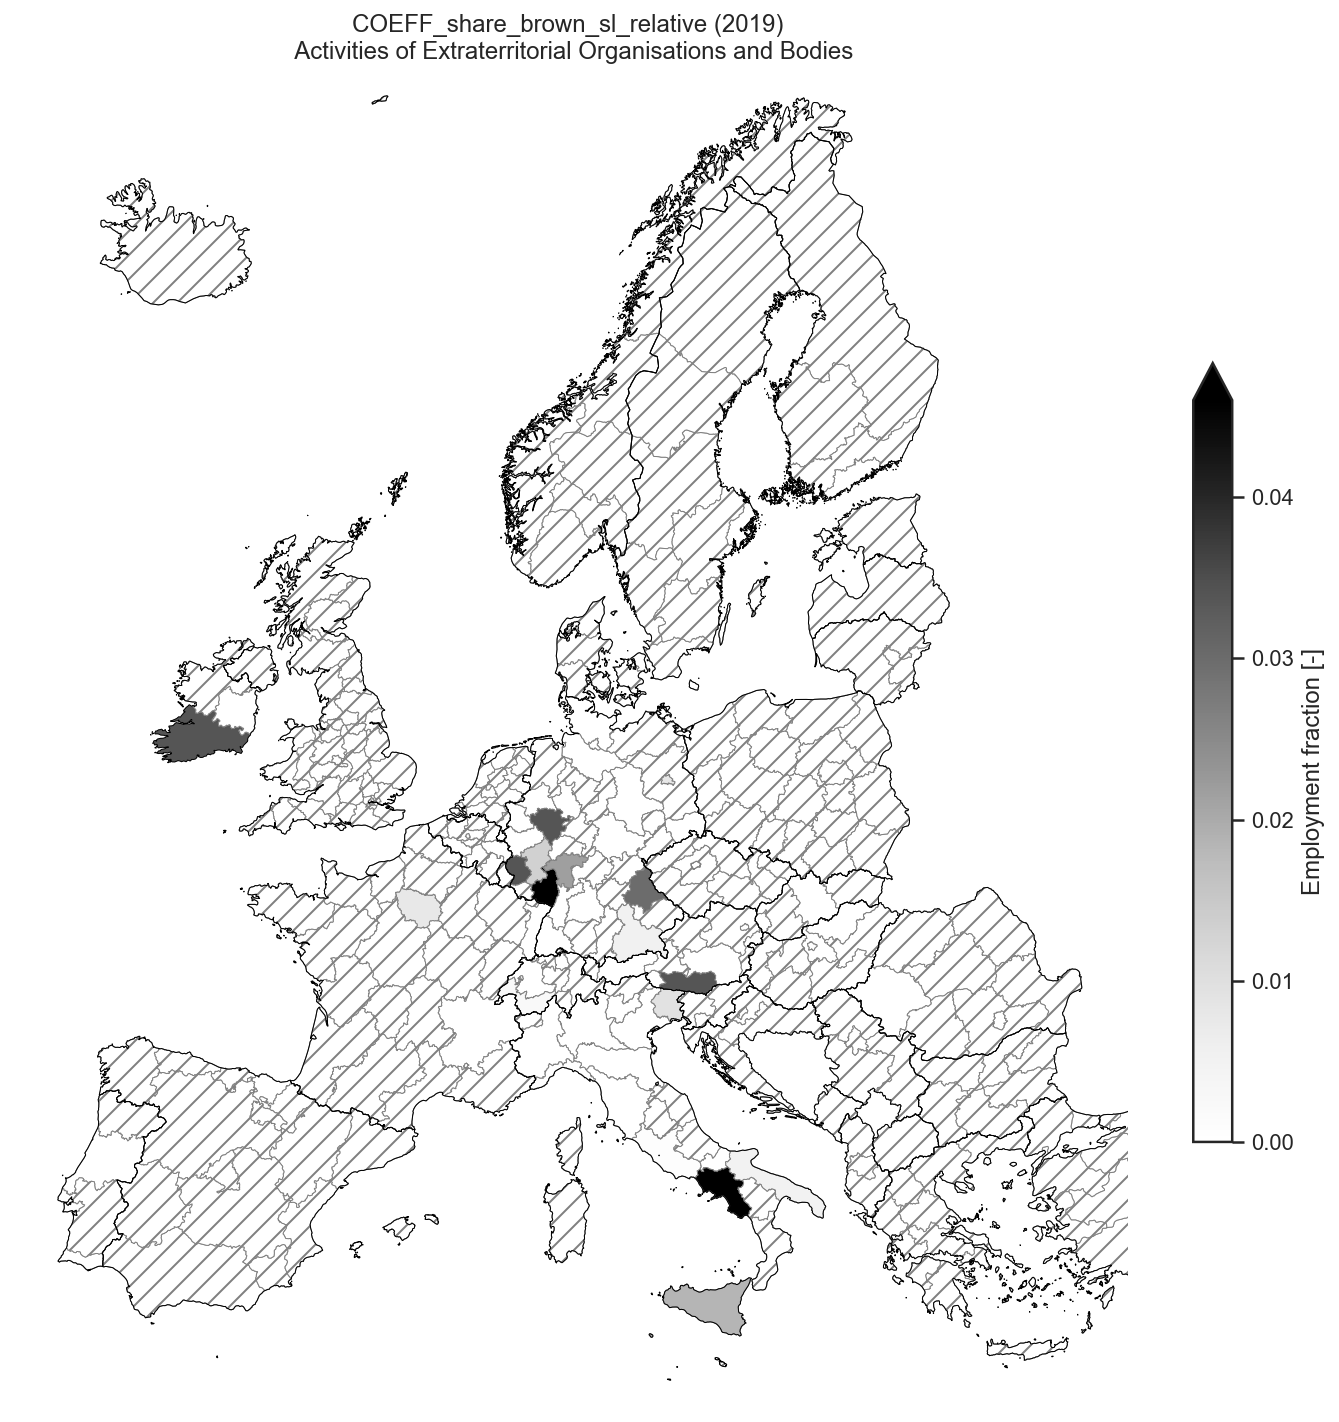

In [74]:
eulfs_visualiser.create_maps(
    slice_by_industry=True,
    vmin=0,
    vmax=None,
    cmap="Greys",
    n_cats=None,
    out_dir=os.path.join(
            useful_paths.figure_dir,
            "03_eulfs",
            "2019",
            "employment_shares_by_region",
            "NEW",
            "by_industry"
        ),
)

Bar charts by country

In [56]:
agg = {
    "NOBS": np.sum,
    "COEFF": np.sum,
    "COEFF_share_brown_sl": np.sum,
    "COEFF_share_brown_slt": np.sum,
    "COEFF_share_green": np.sum,
    "COEFF_share_neutral_sl": np.sum,
    "COEFF_share_neutral_slt": np.sum,
}

data_agg = data_panel_new.groupby(["COUNTRYW", "NACE1D_label"]).aggregate(agg)

# calculate relative shares at regional level
for col in data_agg.columns[data_agg.columns.str.startswith("COEFF_")]:
    data_agg["{}_relative".format(col)] = data_agg[col] / data_agg["COEFF"]

In [65]:
data_agg_final = data_agg[data_agg["NOBS"] >= threshold_a]